# Mạng Nơ-ron Nhân tạo (ANN) với PyTorch trên Cat and Dog

## Lý thuyết về ANN

- ANN là mạng nơ-ron nhân tạo gồm lớp đầu vào, lớp ẩn và lớp đầu ra.
- Với ảnh mèo và chó, ảnh màu sẽ được **resize** về cùng kích thước rồi **flatten** để đưa vào ANN.
- Đây là cách làm đúng theo cấu trúc ANN cơ bản, dù thực tế CNN sẽ hợp với dữ liệu ảnh hơn.


### 2. Cấu trúc ANN

- **Input layer**: số chiều bằng `3 x 64 x 64 = 12288`.
- **Hidden layer 1**: 512 nút.
- **Hidden layer 2**: 128 nút.
- **Output layer**: 1 nút cho bài toán phân loại nhị phân (cat / dog).


### 3. Trọng số và độ chệch

- Trọng số giúp mô hình học đặc trưng ảnh.
- Bias giúp đường phân tách linh hoạt hơn.


### 4. Hàm kích hoạt

- Dùng **ReLU** ở lớp ẩn để tăng khả năng học phi tuyến.
- Ở đầu ra, dùng một giá trị logit và kết hợp với `BCEWithLogitsLoss`.


### 5. Lan truyền tiến (Forward Propagation)

Quy trình:

1. Ảnh màu được resize về `64x64`.
2. Chuyển ảnh thành tensor.
3. Làm phẳng ảnh thành vector 12288 chiều.
4. Đi qua các lớp ẩn.
5. Đầu ra là xác suất ảnh thuộc lớp dog hay cat.


### 6. Hàm mất mát (Loss Function)

- Dùng **BCEWithLogitsLoss** cho bài toán phân loại nhị phân.
- Hàm này ổn định số học hơn so với việc dùng `Sigmoid` rồi `BCELoss` riêng lẻ.


### 7. Lan truyền ngược (Backpropagation)

- Loss được lan truyền ngược để cập nhật trọng số.
- Mô hình dần học cách phân biệt mèo và chó.


In [2]:
# Cài đặt thư viện
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Đặt seed để kết quả ổn định hơn
torch.manual_seed(42)
np.random.seed(42)

# Chọn thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


### 8. Tối ưu hóa (Optimizer)

- Sử dụng **Adam** để tối ưu mô hình.


## Tạo dữ liệu từ Cat and Dog


In [5]:
# Đường dẫn dữ liệu
data_dir = "./data/cat_dog"

# Tiền xử lý dữ liệu
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Tải dữ liệu bằng ImageFolder
dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# Chia train / validation / test
dataset_size = len(dataset)
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

# DataLoader
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Class names:", dataset.classes)
print("Số mẫu train:", len(train_dataset))
print("Số mẫu validation:", len(val_dataset))
print("Số mẫu test:", len(test_dataset))


Class names: ['cat', 'dog']
Số mẫu train: 14
Số mẫu validation: 3
Số mẫu test: 3


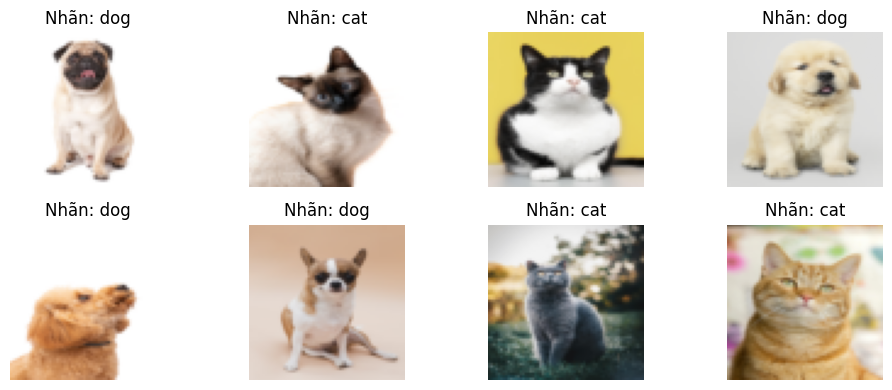

In [6]:
# Hiển thị một vài ảnh mẫu
images, labels = next(iter(train_loader))

num_images = min(len(images), 8)

plt.figure(figsize=(10, 4))
for i in range(num_images):
    plt.subplot(2, 4, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(f"Nhãn: {dataset.classes[labels[i].item()]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Xây ANN bằng PyTorch

ANN đơn giản cho Cat and Dog:


In [7]:
# Xây dựng mô hình ANN cho Cat and Dog
class ANN_CatDog(nn.Module):
    def __init__(self):
        super(ANN_CatDog, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 64 * 64, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)

# Khởi tạo mô hình
model = ANN_CatDog().to(device)

# Định nghĩa mất mát và tối ưu hóa
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

print(model)


ANN_CatDog(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12288, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [8]:
# Hàm đánh giá
def evaluate_model(model, dataloader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc


In [9]:
# Huấn luyện
epochs = 15
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0
    running_correct = 0
    running_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total
    val_loss, val_acc = evaluate_model(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")


Epoch [1/15] | Train Loss: 0.6784 | Train Acc: 64.29% | Val Loss: 1.2446 | Val Acc: 0.00%
Epoch [2/15] | Train Loss: 0.7335 | Train Acc: 57.14% | Val Loss: 0.3321 | Val Acc: 100.00%
Epoch [3/15] | Train Loss: 0.6250 | Train Acc: 57.14% | Val Loss: 0.5467 | Val Acc: 100.00%
Epoch [4/15] | Train Loss: 1.0812 | Train Acc: 64.29% | Val Loss: 1.1239 | Val Acc: 0.00%
Epoch [5/15] | Train Loss: 1.0671 | Train Acc: 42.86% | Val Loss: 0.4438 | Val Acc: 100.00%
Epoch [6/15] | Train Loss: 0.8339 | Train Acc: 57.14% | Val Loss: 0.6614 | Val Acc: 33.33%
Epoch [7/15] | Train Loss: 0.6672 | Train Acc: 64.29% | Val Loss: 1.2375 | Val Acc: 0.00%
Epoch [8/15] | Train Loss: 1.0989 | Train Acc: 50.00% | Val Loss: 1.6172 | Val Acc: 0.00%
Epoch [9/15] | Train Loss: 1.0247 | Train Acc: 50.00% | Val Loss: 1.5522 | Val Acc: 0.00%
Epoch [10/15] | Train Loss: 0.6658 | Train Acc: 57.14% | Val Loss: 1.2108 | Val Acc: 0.00%
Epoch [11/15] | Train Loss: 0.7985 | Train Acc: 50.00% | Val Loss: 1.1482 | Val Acc: 0.00%
E

## Kiểm tra mô hình ANN

ANN đoán đúng bao nhiêu trên dữ liệu kiểm tra.


In [10]:
# Kiểm tra trên tập test
test_loss, test_acc = evaluate_model(model, test_loader)
print(f"Test Loss: {test_loss:.4f}")
print(f"Độ chính xác trên tập test: {test_acc*100:.2f}%")


Test Loss: 0.5981
Độ chính xác trên tập test: 66.67%


## Visualization


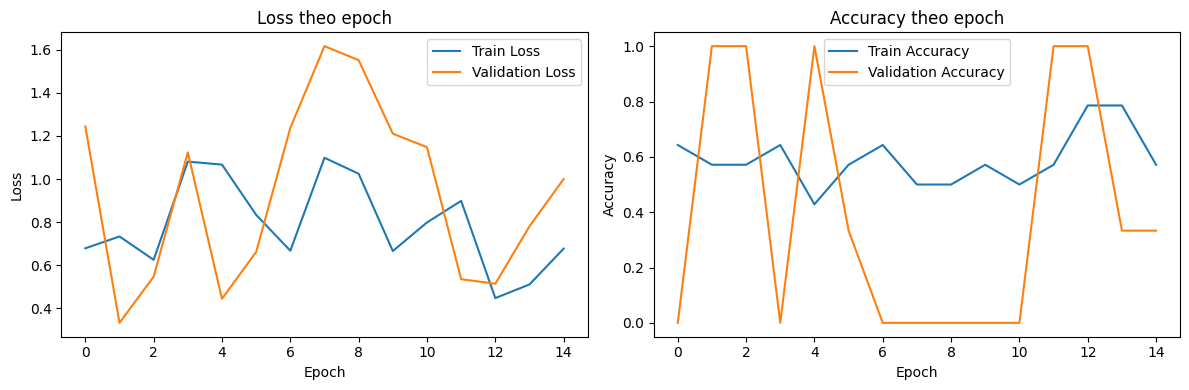

In [11]:
# Vẽ loss và accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss theo epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy theo epoch")
plt.legend()

plt.tight_layout()
plt.show()


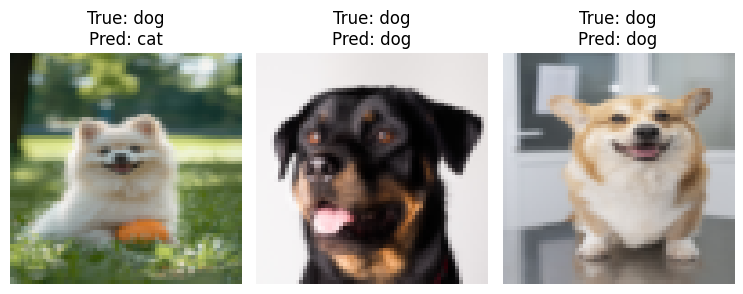

In [12]:
# Hiển thị dự đoán của mô hình trên một vài ảnh test
images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    probs = torch.sigmoid(outputs)
    preds = (probs > 0.5).long().squeeze(1)

num_images = min(len(images), 8)

plt.figure(figsize=(10, 6))
for i in range(num_images):
    plt.subplot(2, 4, i + 1)
    img = images[i].cpu().permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(f"True: {dataset.classes[labels[i].item()]}\nPred: {dataset.classes[preds[i].item()]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Kết luận

- ANN vẫn có thể dùng cho bài toán Cat and Dog nếu ảnh được resize và flatten.
- Tuy nhiên, vì dữ liệu ảnh tự nhiên phức tạp hơn MNIST rất nhiều, hiệu quả của ANN thường kém hơn CNN.
- Notebook này phù hợp để bám sát **cấu trúc file lab ANN**, đồng thời thử nghiệm trên dữ liệu thực tế.
